In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/luisfelipevendramim/home-credit-default-risk-pipeline-otimizada/notebook_home_credit_otimizado.ipynb
/kaggle/input/competitions/home-credit-default-risk/sample_submission.csv
/kaggle/input/competitions/home-credit-default-risk/bureau_balance.csv
/kaggle/input/competitions/home-credit-default-risk/POS_CASH_balance.csv
/kaggle/input/competitions/home-credit-default-risk/application_train.csv
/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv
/kaggle/input/competitions/home-credit-default-risk/application_test.csv
/kaggle/input/competitions/home-credit-default-risk/previous_application.csv
/kaggle/input/competitions/home-credit-default-risk/credit_card_balance.csv
/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv
/kaggle/input/competitions/home-credit-default-risk/bureau.csv


In [23]:
import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception as e:
    HAS_LGBM = False
    print("LightGBM não disponível:", e)

DATA_DIR = "/kaggle/input/competitions/home-credit-default-risk"
RANDOM_STATE = 42
N_SPLITS = 5

In [24]:
def optimize_memory(df):
    """Reduz uso de memória sem alterar a lógica das features."""
    for col in df.select_dtypes(include=["int64", "int32"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    for col in df.select_dtypes(include=["float64", "float32"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="float")

    return df


def clean_column_names(df):
    df.columns = (
        pd.Series(df.columns)
        .astype(str)
        .str.replace(r"[^0-9a-zA-Z_]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
        .tolist()
    )
    return df


def add_ratio_features(df):
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
    df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / (df["AMT_INCOME_TOTAL"] + 1e-6)
    df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + 1e-6)
    df["CREDIT_ANNUITY_RATIO"] = df["AMT_CREDIT"] / (df["AMT_ANNUITY"] + 1e-6)
    df["DAYS_EMPLOYED_RATIO"] = df["DAYS_EMPLOYED"] / (df["DAYS_BIRTH"] + 1e-6)
    df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / (df["CNT_FAM_MEMBERS"] + 1e-6)
    return df


def encode_categoricals_as_codes(df):
    """Mais leve que get_dummies: transforma categorias em códigos numéricos."""
    cat_cols = df.select_dtypes(include="object").columns
    for col in cat_cols:
        df[col] = df[col].astype("category").cat.codes.astype("int16")
    return df


def safe_merge(base, features, name):
    print(f"Merging {name}: base={base.shape}, features={features.shape}")
    base = base.merge(features, on="SK_ID_CURR", how="left")
    del features
    gc.collect()
    return optimize_memory(base)

1. Carregamento da Base Principal

In [25]:
train = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "application_test.csv"))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(train.shape, test.shape, sample_submission.shape)

(307511, 122) (48744, 121) (48744, 2)


In [26]:
y = train["TARGET"].astype("int8").copy()
test_ids = test["SK_ID_CURR"].copy()

app = pd.concat(
    [train.drop(columns=["TARGET"]), test],
    axis=0,
    ignore_index=True
)

del train, test
gc.collect()

app = add_ratio_features(app)
app = encode_categoricals_as_codes(app)
app = app.replace([np.inf, -np.inf], np.nan)
app = optimize_memory(app)

print(app.shape)
app.head()

(356255, 126)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,DAYS_EMPLOYED_RATIO,INCOME_PER_PERSON
0,100002,0,1,0,1,0,202500.0,406597.5,24700.5,351000.0,...,0.0,0.0,0.0,0.0,1.0,2.007889,0.121978,16.461103,0.067329,202499.79750
1,100003,0,0,0,0,0,270000.0,1293502.5,35698.5,1129500.0,...,0.0,0.0,0.0,0.0,0.0,4.790750,0.132217,36.234085,0.070862,134999.93250
2,100004,1,1,1,1,0,67500.0,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,0.0,0.0,2.000000,0.100000,20.000000,0.011814,67499.93250
3,100006,0,0,0,1,0,135000.0,312682.5,29686.5,297000.0,...,NaN,NaN,NaN,NaN,NaN,2.316167,0.219900,10.532818,0.159905,67499.96625
4,100007,0,1,0,1,0,121500.0,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,0.0,0.0,4.222222,0.179963,23.461618,0.152418,121499.87850


2. Features Agregadas Leves
As tabelas auxiliares são processadas uma por vez. Isso evita manter várias bases grandes abertas ao mesmo tempo.

In [27]:
def process_bureau():
    bureau_cols = [
        "SK_ID_CURR", "SK_ID_BUREAU", "DAYS_CREDIT", "CREDIT_DAY_OVERDUE",
        "DAYS_CREDIT_ENDDATE", "AMT_CREDIT_MAX_OVERDUE", "CNT_CREDIT_PROLONG",
        "AMT_CREDIT_SUM", "AMT_CREDIT_SUM_DEBT", "AMT_CREDIT_SUM_LIMIT",
        "AMT_CREDIT_SUM_OVERDUE", "DAYS_CREDIT_UPDATE", "AMT_ANNUITY"
    ]
    bb_cols = ["SK_ID_BUREAU", "MONTHS_BALANCE"]

    bureau = pd.read_csv(os.path.join(DATA_DIR, "bureau.csv"), usecols=bureau_cols)
    bb = pd.read_csv(os.path.join(DATA_DIR, "bureau_balance.csv"), usecols=bb_cols)

    bureau = optimize_memory(bureau)
    bb = optimize_memory(bb)

    bb_agg = bb.groupby("SK_ID_BUREAU").agg(
        BB_MONTHS_BALANCE_MEAN=("MONTHS_BALANCE", "mean"),
        BB_MONTHS_BALANCE_MIN=("MONTHS_BALANCE", "min"),
        BB_MONTHS_BALANCE_MAX=("MONTHS_BALANCE", "max"),
        BB_RECORD_COUNT=("MONTHS_BALANCE", "count"),
    ).reset_index()

    del bb
    gc.collect()

    bureau = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")
    del bb_agg
    gc.collect()

    bureau_agg = bureau.groupby("SK_ID_CURR").agg(
        BUREAU_LOAN_COUNT=("SK_ID_BUREAU", "count"),
        BUREAU_DAYS_CREDIT_MEAN=("DAYS_CREDIT", "mean"),
        BUREAU_DAYS_CREDIT_MIN=("DAYS_CREDIT", "min"),
        BUREAU_CREDIT_OVERDUE_MEAN=("CREDIT_DAY_OVERDUE", "mean"),
        BUREAU_CREDIT_SUM_MEAN=("AMT_CREDIT_SUM", "mean"),
        BUREAU_CREDIT_SUM_MAX=("AMT_CREDIT_SUM", "max"),
        BUREAU_DEBT_MEAN=("AMT_CREDIT_SUM_DEBT", "mean"),
        BUREAU_DEBT_SUM=("AMT_CREDIT_SUM_DEBT", "sum"),
        BUREAU_LIMIT_MEAN=("AMT_CREDIT_SUM_LIMIT", "mean"),
        BUREAU_ANNUITY_MEAN=("AMT_ANNUITY", "mean"),
        BB_RECORD_COUNT_MEAN=("BB_RECORD_COUNT", "mean"),
    ).reset_index()

    del bureau
    gc.collect()

    return optimize_memory(bureau_agg)

In [28]:
def process_pos():
    cols = [
        "SK_ID_CURR", "MONTHS_BALANCE", "CNT_INSTALMENT",
        "CNT_INSTALMENT_FUTURE", "SK_DPD", "SK_DPD_DEF"
    ]
    pos = pd.read_csv(os.path.join(DATA_DIR, "POS_CASH_balance.csv"), usecols=cols)
    pos = optimize_memory(pos)

    pos_agg = pos.groupby("SK_ID_CURR").agg(
        POS_MONTHS_BALANCE_MEAN=("MONTHS_BALANCE", "mean"),
        POS_MONTHS_BALANCE_MIN=("MONTHS_BALANCE", "min"),
        POS_INSTALMENT_MEAN=("CNT_INSTALMENT", "mean"),
        POS_INSTALMENT_FUTURE_MEAN=("CNT_INSTALMENT_FUTURE", "mean"),
        POS_DPD_MEAN=("SK_DPD", "mean"),
        POS_DPD_MAX=("SK_DPD", "max"),
        POS_DPD_DEF_MEAN=("SK_DPD_DEF", "mean"),
        POS_RECORD_COUNT=("SK_DPD", "count"),
    ).reset_index()

    del pos
    gc.collect()
    return optimize_memory(pos_agg)

In [29]:
def process_credit_card():
    cols = [
        "SK_ID_CURR", "MONTHS_BALANCE", "AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL",
        "AMT_PAYMENT_TOTAL_CURRENT", "AMT_DRAWINGS_CURRENT", "SK_DPD", "SK_DPD_DEF"
    ]
    cc = pd.read_csv(os.path.join(DATA_DIR, "credit_card_balance.csv"), usecols=cols)
    cc = optimize_memory(cc)
    cc["CC_LIMIT_USE_RATIO"] = cc["AMT_BALANCE"] / (cc["AMT_CREDIT_LIMIT_ACTUAL"] + 1e-6)

    cc_agg = cc.groupby("SK_ID_CURR").agg(
        CC_BALANCE_MEAN=("AMT_BALANCE", "mean"),
        CC_BALANCE_MAX=("AMT_BALANCE", "max"),
        CC_LIMIT_MEAN=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
        CC_PAYMENT_MEAN=("AMT_PAYMENT_TOTAL_CURRENT", "mean"),
        CC_DRAWINGS_MEAN=("AMT_DRAWINGS_CURRENT", "mean"),
        CC_DPD_MEAN=("SK_DPD", "mean"),
        CC_DPD_MAX=("SK_DPD", "max"),
        CC_LIMIT_USE_MEAN=("CC_LIMIT_USE_RATIO", "mean"),
        CC_LIMIT_USE_MAX=("CC_LIMIT_USE_RATIO", "max"),
        CC_RECORD_COUNT=("MONTHS_BALANCE", "count"),
    ).reset_index()

    del cc
    gc.collect()
    return optimize_memory(cc_agg)

In [30]:
def process_installments():
    cols = [
        "SK_ID_CURR", "NUM_INSTALMENT_VERSION", "DAYS_INSTALMENT",
        "DAYS_ENTRY_PAYMENT", "AMT_INSTALMENT", "AMT_PAYMENT"
    ]
    ins = pd.read_csv(os.path.join(DATA_DIR, "installments_payments.csv"), usecols=cols)
    ins = optimize_memory(ins)

    ins["PAYMENT_RATIO"] = ins["AMT_PAYMENT"] / (ins["AMT_INSTALMENT"] + 1e-6)
    ins["PAYMENT_DIFF"] = ins["AMT_PAYMENT"] - ins["AMT_INSTALMENT"]
    ins["DPD"] = np.maximum(ins["DAYS_ENTRY_PAYMENT"] - ins["DAYS_INSTALMENT"], 0)
    ins["DBD"] = np.maximum(ins["DAYS_INSTALMENT"] - ins["DAYS_ENTRY_PAYMENT"], 0)

    ins_agg = ins.groupby("SK_ID_CURR").agg(
        INS_PAYMENT_RATIO_MEAN=("PAYMENT_RATIO", "mean"),
        INS_PAYMENT_RATIO_MIN=("PAYMENT_RATIO", "min"),
        INS_PAYMENT_DIFF_MEAN=("PAYMENT_DIFF", "mean"),
        INS_PAYMENT_DIFF_MAX=("PAYMENT_DIFF", "max"),
        INS_DPD_MEAN=("DPD", "mean"),
        INS_DPD_MAX=("DPD", "max"),
        INS_DBD_MEAN=("DBD", "mean"),
        INS_PAYMENT_SUM=("AMT_PAYMENT", "sum"),
        INS_INSTALMENT_SUM=("AMT_INSTALMENT", "sum"),
        INS_RECORD_COUNT=("AMT_PAYMENT", "count"),
    ).reset_index()

    del ins
    gc.collect()
    return optimize_memory(ins_agg)

In [31]:
def process_previous_application():
    cols = [
        "SK_ID_CURR", "AMT_ANNUITY", "AMT_APPLICATION", "AMT_CREDIT",
        "AMT_DOWN_PAYMENT", "AMT_GOODS_PRICE", "HOUR_APPR_PROCESS_START",
        "RATE_DOWN_PAYMENT", "DAYS_DECISION", "CNT_PAYMENT"
    ]
    prev = pd.read_csv(os.path.join(DATA_DIR, "previous_application.csv"), usecols=cols)
    prev = optimize_memory(prev)
    prev["PREV_CREDIT_APPLICATION_RATIO"] = prev["AMT_CREDIT"] / (prev["AMT_APPLICATION"] + 1e-6)

    prev_agg = prev.groupby("SK_ID_CURR").agg(
        PREV_APPLICATION_MEAN=("AMT_APPLICATION", "mean"),
        PREV_CREDIT_MEAN=("AMT_CREDIT", "mean"),
        PREV_CREDIT_MAX=("AMT_CREDIT", "max"),
        PREV_ANNUITY_MEAN=("AMT_ANNUITY", "mean"),
        PREV_DOWN_PAYMENT_MEAN=("AMT_DOWN_PAYMENT", "mean"),
        PREV_DAYS_DECISION_MEAN=("DAYS_DECISION", "mean"),
        PREV_CNT_PAYMENT_MEAN=("CNT_PAYMENT", "mean"),
        PREV_CREDIT_APPLICATION_RATIO_MEAN=("PREV_CREDIT_APPLICATION_RATIO", "mean"),
        PREV_RECORD_COUNT=("AMT_CREDIT", "count"),
    ).reset_index()

    del prev
    gc.collect()
    return optimize_memory(prev_agg)

In [32]:
# Execute uma tabela por vez. Se o Kaggle ficar pesado, comente as últimas duas linhas.
app = safe_merge(app, process_bureau(), "bureau")
app = safe_merge(app, process_pos(), "POS_CASH")
app = safe_merge(app, process_credit_card(), "credit_card")
app = safe_merge(app, process_installments(), "installments")
app = safe_merge(app, process_previous_application(), "previous_application")

app = clean_column_names(app)
app = app.replace([np.inf, -np.inf], np.nan)
app = optimize_memory(app)

print(app.shape)

Merging bureau: base=(356255, 126), features=(305811, 12)
Merging POS_CASH: base=(356255, 137), features=(337252, 9)
Merging credit_card: base=(356255, 145), features=(103558, 11)
Merging installments: base=(356255, 155), features=(339587, 11)
Merging previous_application: base=(356255, 165), features=(338857, 10)
(356255, 174)


3. Separação Treino/Teste

In [33]:
X = app.iloc[:len(y)].copy()
X_test = app.iloc[len(y):].copy()

X = X.drop(columns=["SK_ID_CURR"])
X_test = X_test.drop(columns=["SK_ID_CURR"])

# Garante mesmas colunas e ordem.
X_test = X_test.reindex(columns=X.columns)

# Libera a base concatenada.
del app
gc.collect()

print("X:", X.shape)
print("X_test:", X_test.shape)

X: (307511, 173)
X_test: (48744, 173)


4. Validação ROC AUC

In [34]:
def cross_validate_lightgbm(X, y, n_splits=N_SPLITS):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    oof = np.zeros(len(X), dtype="float32")

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = LGBMClassifier(
            n_estimators=700,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            subsample=0.85,
            colsample_bytree=0.85,
            min_child_samples=80,
            reg_alpha=0.1,
            reg_lambda=0.1,
            class_weight="balanced",
            random_state=RANDOM_STATE + fold,
            n_jobs=-1,
            verbose=-1,
        )

        model.fit(X_tr, y_tr)
        pred = model.predict_proba(X_va)[:, 1]
        oof[va_idx] = pred
        score = roc_auc_score(y_va, pred)
        scores.append(score)
        print(f"Fold {fold}: {score:.5f}")

        del X_tr, X_va, y_tr, y_va, model, pred
        gc.collect()

    print(f"LightGBM ROC AUC médio: {np.mean(scores):.5f} | std: {np.std(scores):.5f}")
    print(f"LightGBM OOF ROC AUC: {roc_auc_score(y, oof):.5f}")
    return np.mean(scores)

In [35]:
def cross_validate_logistic(X, y, n_splits=N_SPLITS):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", LogisticRegression(
            max_iter=500,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ))
    ])

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model.fit(X_tr, y_tr)
        pred = model.predict_proba(X_va)[:, 1]
        score = roc_auc_score(y_va, pred)
        scores.append(score)
        print(f"Fold {fold}: {score:.5f}")

        del X_tr, X_va, y_tr, y_va, pred
        gc.collect()

    print(f"Logistic Regression ROC AUC médio: {np.mean(scores):.5f} | std: {np.std(scores):.5f}")
    return np.mean(scores)

In [36]:
results = {}

# Baseline leve. Se ficar lento, pule esta célula e rode só LightGBM.
results["Logistic Regression"] = cross_validate_logistic(X, y)

if HAS_LGBM:
    results["LightGBM"] = cross_validate_lightgbm(X, y)

pd.Series(results).sort_values(ascending=False)

Fold 1: 0.62046
Fold 2: 0.62685
Fold 3: 0.64245
Fold 4: 0.59068
Fold 5: 0.63791
Logistic Regression ROC AUC médio: 0.62367 | std: 0.01824
Fold 1: 0.78217
Fold 2: 0.78982
Fold 3: 0.78206
Fold 4: 0.78675
Fold 5: 0.78029
LightGBM ROC AUC médio: 0.78422 | std: 0.00353
LightGBM OOF ROC AUC: 0.78419


LightGBM               0.784217
Logistic Regression    0.623670
dtype: float64

4.1 Tuning controlado do LightGBM

Esta etapa testa poucas combinações de hiperparâmetros para verificar se existe ganho real de ROC AUC sem aumentar demais a complexidade do projeto. Se o melhor resultado superar o LightGBM original, o notebook passa a usar esses parâmetros no treino final.

In [37]:
def cross_validate_lightgbm_with_params(X, y, params, n_splits=N_SPLITS):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        model = LGBMClassifier(
            **params,
            class_weight="balanced",
            random_state=RANDOM_STATE + fold,
            n_jobs=-1,
            verbose=-1,
        )

        model.fit(X_tr, y_tr)
        pred = model.predict_proba(X_va)[:, 1]
        score = roc_auc_score(y_va, pred)
        scores.append(score)
        print(f"Fold {fold}: {score:.5f}")

        del X_tr, X_va, y_tr, y_va, model, pred
        gc.collect()

    return np.mean(scores), np.std(scores)


lgbm_param_grid = [
    {
        "name": "Baseline",
        "params": {
            "n_estimators": 700,
            "learning_rate": 0.03,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "min_child_samples": 80,
            "reg_alpha": 0.1,
            "reg_lambda": 0.1,
        },
    },

    {
        "name": "Low LR",
        "params": {
            "n_estimators": 1200,
            "learning_rate": 0.02,
            "num_leaves": 31,
            "max_depth": -1,
            "subsample": 0.85,
            "colsample_bytree": 0.80,
            "min_child_samples": 100,
            "reg_alpha": 0.2,
            "reg_lambda": 0.2,
        },
    },

    {
        "name": "More Leaves",
        "params": {
            "n_estimators": 1000,
            "learning_rate": 0.025,
            "num_leaves": 48,
            "max_depth": -1,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "min_child_samples": 120,
            "reg_alpha": 0.3,
            "reg_lambda": 0.3,
        },
    },

    {
        "name": "Aggressive",
        "params": {
            "n_estimators": 1500,
            "learning_rate": 0.015,
            "num_leaves": 64,
            "max_depth": -1,
            "subsample": 0.80,
            "colsample_bytree": 0.80,
            "min_child_samples": 150,
            "reg_alpha": 0.5,
            "reg_lambda": 0.5,
        },
    },

    {
        "name": "Regularized",
        "params": {
            "n_estimators": 1000,
            "learning_rate": 0.02,
            "num_leaves": 31,
            "max_depth": 8,
            "subsample": 0.75,
            "colsample_bytree": 0.75,
            "min_child_samples": 150,
            "reg_alpha": 1.0,
            "reg_lambda": 1.0,
        },
    },

    {
        "name": "Balanced",
        "params": {
            "n_estimators": 1300,
            "learning_rate": 0.02,
            "num_leaves": 40,
            "max_depth": 10,
            "subsample": 0.85,
            "colsample_bytree": 0.85,
            "min_child_samples": 100,
            "reg_alpha": 0.2,
            "reg_lambda": 0.2,
        },
    },
]

if not HAS_LGBM:
    raise RuntimeError("LightGBM não está disponível neste ambiente.")

tuning_results = []

for config in lgbm_param_grid:
    print(f"\nTestando: {config['name']}")
    mean_auc, std_auc = cross_validate_lightgbm_with_params(X, y, config["params"])
    tuning_results.append({
        "model": config["name"],
        "roc_auc_mean": mean_auc,
        "roc_auc_std": std_auc,
        "params": config["params"],
    })
    print(f"ROC AUC m?dio: {mean_auc:.5f} | std: {std_auc:.5f}")

lgbm_tuning_results = pd.DataFrame(tuning_results).sort_values("roc_auc_mean", ascending=False)
best_lgbm_row = lgbm_tuning_results.iloc[0]
best_lgbm_params = best_lgbm_row["params"]
best_lgbm_score = best_lgbm_row["roc_auc_mean"]

results["LightGBM Tuned"] = best_lgbm_score

print("\nMelhor configuração encontrada:", best_lgbm_row["model"])
print(f"Melhor ROC AUC m?dio: {best_lgbm_score:.5f}")

lgbm_tuning_results.drop(columns=["params"])


Testando: Baseline
Fold 1: 0.78217
Fold 2: 0.78982
Fold 3: 0.78206
Fold 4: 0.78675
Fold 5: 0.78029
ROC AUC m?dio: 0.78422 | std: 0.00353

Testando: Low LR
Fold 1: 0.78243
Fold 2: 0.78963
Fold 3: 0.78252
Fold 4: 0.78818
Fold 5: 0.78128
ROC AUC m?dio: 0.78481 | std: 0.00341

Testando: More Leaves
Fold 1: 0.78275
Fold 2: 0.78957
Fold 3: 0.78287
Fold 4: 0.78672
Fold 5: 0.78074
ROC AUC m?dio: 0.78453 | std: 0.00318

Testando: Aggressive
Fold 1: 0.78275
Fold 2: 0.78929
Fold 3: 0.78356
Fold 4: 0.78808
Fold 5: 0.78082
ROC AUC m?dio: 0.78490 | std: 0.00324

Testando: Regularized
Fold 1: 0.78283
Fold 2: 0.79091
Fold 3: 0.78309
Fold 4: 0.78805
Fold 5: 0.78057
ROC AUC m?dio: 0.78509 | std: 0.00380

Testando: Balanced
Fold 1: 0.78212
Fold 2: 0.78963
Fold 3: 0.78248
Fold 4: 0.78734
Fold 5: 0.78028
ROC AUC m?dio: 0.78437 | std: 0.00352

Melhor configuração encontrada: Regularized
Melhor ROC AUC m?dio: 0.78509


,model,roc_auc_mean,roc_auc_std
4,Regularized,0.785089,0.003800
3,Aggressive,0.784897,0.003238
1,Low LR,0.784806,0.003406
2,More Leaves,0.784531,0.003178
5,Balanced,0.784369,0.003517
0,Baseline,0.784217,0.003525


Comparação de performance dos modelos

O gráfico abaixo compara o ROC AUC da Regressão Logística, usada como baseline, com o LightGBM. Quanto maior o ROC AUC, melhor a capacidade do modelo de separar clientes com maior e menor risco de inadimplência.

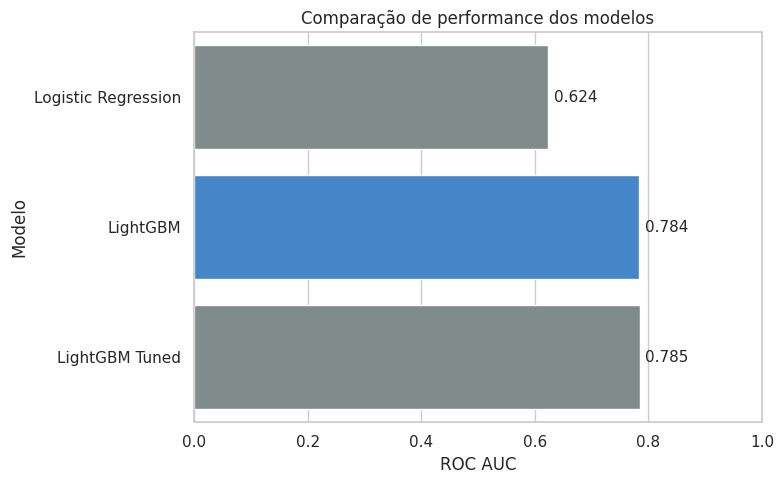

,model,roc_auc
2,LightGBM Tuned,0.785089
1,LightGBM,0.784217
0,Logistic Regression,0.623670


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

model_auc = (
    pd.Series(results, name="roc_auc")
    .rename_axis("model")
    .reset_index()
    .sort_values("roc_auc")
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=model_auc,
    x="roc_auc",
    y="model",
    palette=["#7f8c8d", "#2e86de"],
)

ax.set_title("Comparação de performance dos modelos")
ax.set_xlabel("ROC AUC")
ax.set_ylabel("Modelo")
ax.set_xlim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4, fontsize=11)

plt.tight_layout()
plt.savefig("comparacao_roc_auc_modelos.png", dpi=180, bbox_inches="tight")
plt.show()

model_auc.sort_values("roc_auc", ascending=False)

5. Treino Final e Submissão

In [39]:
if not HAS_LGBM:
    raise RuntimeError("LightGBM não está disponível neste ambiente.")

# Se a etapa de tuning foi executada, usa a melhor configuração encontrada.
# Caso contrário, mantém os hiperparâmetros originais do treino final.
default_lgbm_final_params = {
    "n_estimators": 900,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_samples": 80,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
}

selected_lgbm_params = globals().get("best_lgbm_params", default_lgbm_final_params)
selected_lgbm_score = globals().get("best_lgbm_score", results.get("LightGBM"))

print("Parâmetros usados no modelo final:")
print(selected_lgbm_params)
if selected_lgbm_score is not None:
    print(f"ROC AUC médio de validação da configuração selecionada: {selected_lgbm_score:.5f}")

final_model = LGBMClassifier(
    **selected_lgbm_params,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

final_model.fit(X, y)
test_preds = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "SK_ID_CURR": test_ids,
    "TARGET": test_preds
})

submission.to_csv("submission.csv", index=False)
submission.head()

Parâmetros usados no modelo final:
{'n_estimators': 1000, 'learning_rate': 0.02, 'num_leaves': 31, 'max_depth': 8, 'subsample': 0.75, 'colsample_bytree': 0.75, 'min_child_samples': 150, 'reg_alpha': 1.0, 'reg_lambda': 1.0}
ROC AUC médio de validação da configuração selecionada: 0.78509


,SK_ID_CURR,TARGET
0,100001,0.259607
1,100005,0.626686
2,100013,0.154376
3,100028,0.220523
4,100038,0.691910


In [40]:
# Importância das variáveis para entender o modelo
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance.head(30)

,feature,importance
122,CREDIT_ANNUITY_RATIO,1467
39,EXT_SOURCE_1,1176
41,EXT_SOURCE_3,1133
40,EXT_SOURCE_2,922
15,DAYS_BIRTH,844
139,POS_INSTALMENT_FUTURE_MEAN,684
16,DAYS_EMPLOYED,569
7,AMT_ANNUITY,563
161,INS_PAYMENT_SUM,494
126,BUREAU_DAYS_CREDIT_MEAN,483


6. Visualização da Importância das Variáveis

Os gráficos abaixo ajudam a interpretar quais variáveis mais contribuíram para o LightGBM final. A importância nativa do LightGBM mede a frequência/ganho das divisões usadas pelas árvores e deve ser lida como uma indicação de influência do modelo, não como causalidade.

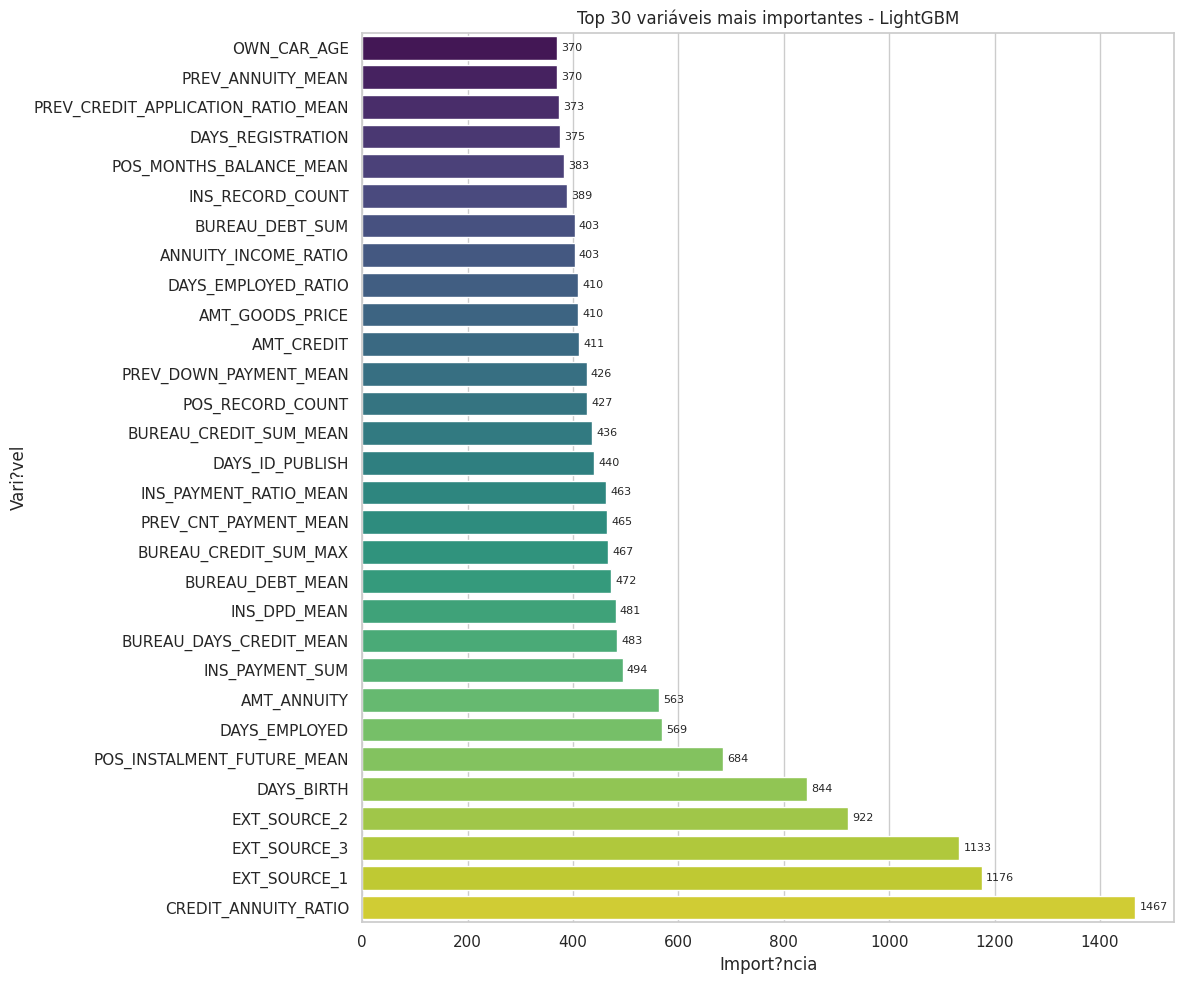

,feature,importance,importance_pct
122,CREDIT_ANNUITY_RATIO,1467,4.890000
39,EXT_SOURCE_1,1176,3.920000
41,EXT_SOURCE_3,1133,3.776667
40,EXT_SOURCE_2,922,3.073333
15,DAYS_BIRTH,844,2.813333
139,POS_INSTALMENT_FUTURE_MEAN,684,2.280000
16,DAYS_EMPLOYED,569,1.896667
7,AMT_ANNUITY,563,1.876667
161,INS_PAYMENT_SUM,494,1.646667
126,BUREAU_DAYS_CREDIT_MEAN,483,1.610000


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")

top_n = 30
top_features = feature_importance.head(top_n).copy()
top_features["importance_pct"] = (
    top_features["importance"] / feature_importance["importance"].sum() * 100
)

plt.figure(figsize=(12, 10))
ax = sns.barplot(
    data=top_features.sort_values("importance", ascending=True),
    x="importance",
    y="feature",
    palette="viridis",
)
ax.set_title(f"Top {top_n} variáveis mais importantes - LightGBM")
ax.set_xlabel("Import?ncia")
ax.set_ylabel("Vari?vel")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

top_features[["feature", "importance", "importance_pct"]].head(10)

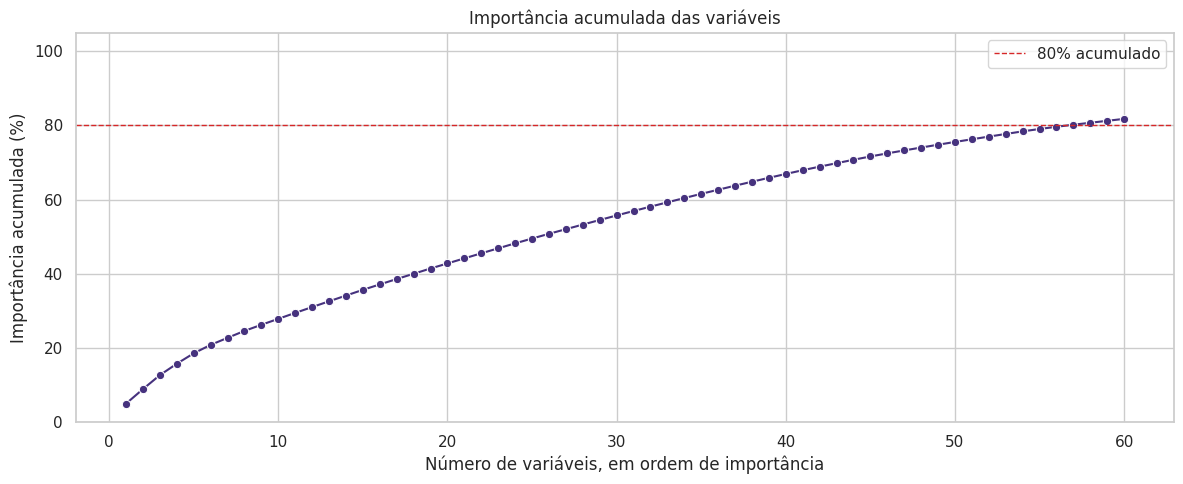

,feature,importance,importance_pct,cumulative_importance_pct
122,CREDIT_ANNUITY_RATIO,1467,4.890000,4.890000
39,EXT_SOURCE_1,1176,3.920000,8.810000
41,EXT_SOURCE_3,1133,3.776667,12.586667
40,EXT_SOURCE_2,922,3.073333,15.660000
15,DAYS_BIRTH,844,2.813333,18.473333
139,POS_INSTALMENT_FUTURE_MEAN,684,2.280000,20.753333
16,DAYS_EMPLOYED,569,1.896667,22.650000
7,AMT_ANNUITY,563,1.876667,24.526667
161,INS_PAYMENT_SUM,494,1.646667,26.173333
126,BUREAU_DAYS_CREDIT_MEAN,483,1.610000,27.783333


In [42]:
feature_importance_plot = feature_importance.copy()
feature_importance_plot["importance_pct"] = (
    feature_importance_plot["importance"] / feature_importance_plot["importance"].sum() * 100
)
feature_importance_plot["cumulative_importance_pct"] = feature_importance_plot["importance_pct"].cumsum()

plt.figure(figsize=(12, 5))
ax = sns.lineplot(
    data=feature_importance_plot.head(60),
    x=range(1, min(60, len(feature_importance_plot)) + 1),
    y="cumulative_importance_pct",
    marker="o",
)
ax.axhline(80, color="#d62728", linestyle="--", linewidth=1, label="80% acumulado")
ax.set_title("Importância acumulada das variáveis")
ax.set_xlabel("Número de variáveis, em ordem de importância")
ax.set_ylabel("Importância acumulada (%)")
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

feature_importance_plot.head(30)

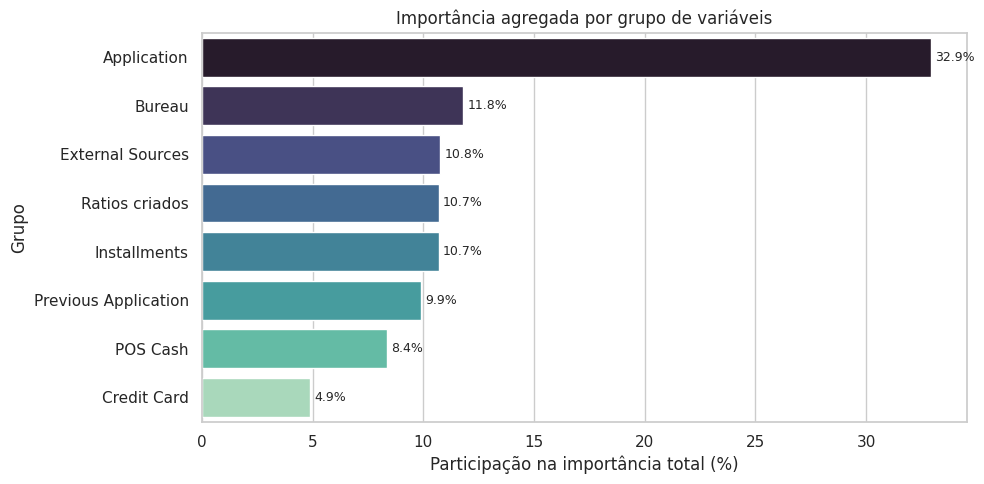

,group,importance,importance_pct
0,Application,9874,32.913333
1,Bureau,3540,11.800000
3,External Sources,3231,10.770000
7,Ratios criados,3211,10.703333
4,Installments,3207,10.690000
6,Previous Application,2965,9.883333
5,POS Cash,2510,8.366667
2,Credit Card,1462,4.873333


In [43]:
def feature_group(feature_name):
    if feature_name.startswith("BUREAU") or feature_name.startswith("BB_"):
        return "Bureau"
    if feature_name.startswith("POS_"):
        return "POS Cash"
    if feature_name.startswith("CC_"):
        return "Credit Card"
    if feature_name.startswith("INS_"):
        return "Installments"
    if feature_name.startswith("PREV_"):
        return "Previous Application"
    if feature_name.startswith("EXT_SOURCE"):
        return "External Sources"
    if "RATIO" in feature_name or "PER_PERSON" in feature_name:
        return "Ratios criados"
    return "Application"

feature_groups = feature_importance.copy()
feature_groups["group"] = feature_groups["feature"].map(feature_group)
feature_groups = (
    feature_groups.groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
feature_groups["importance_pct"] = (
    feature_groups["importance"] / feature_groups["importance"].sum() * 100
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=feature_groups,
    x="importance_pct",
    y="group",
    palette="mako",
)
ax.set_title("Importância agregada por grupo de variáveis")
ax.set_xlabel("Participação na importância total (%)")
ax.set_ylabel("Grupo")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

feature_groups